In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from medmnist import INFO, PathMNIST

sns.set_theme(style = "whitegrid")

# Exploratory Analysis

Firstly, we divide the PathMNIST dataset into train and test subsets and explore their sizes.

In [181]:
train_dataset = PathMNIST(split = 'train',
                        transform = None,
                        download = True)
val_dataset = PathMNIST(split = 'val',
                        transform = None,
                        download = True)
test_dataset = PathMNIST(split = 'test',
                        transform = None,
                        download = True)

# Each sample consists of an image and a label
# e.g. train_data[0][0] contains image_data & train_data[0][1] contains label

# Table of every image in dataset
train_images = train_dataset.imgs
val_images = val_dataset.imgs
test_images = test_dataset.imgs

print(f"""Loaded:
    - {train_images.shape[0]} training images,
    - {val_images.shape[0]} validation images,
    - {test_images.shape[0]} test images,
    of shape {train_images.shape[1:]}""")

Using downloaded and verified file: C:\Users\Tomek\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Tomek\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Tomek\.medmnist\pathmnist.npz
Loaded:
    - 89996 training images,
    - 10004 validation images,
    - 7180 test images,
    of shape (28, 28, 3)


In [182]:
train_dataset.info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

Each sample consists of an image and a label (class). There are nine labels, numbered from 0 to 8, and each corresponds to a different type of tissue.

In [183]:
label_dict = train_dataset.info['label']
class_names = list(label_dict.values())
n_classes = len(class_names)

label_dict

{'0': 'adipose',
 '1': 'background',
 '2': 'debris',
 '3': 'lymphocytes',
 '4': 'mucus',
 '5': 'smooth muscle',
 '6': 'normal colon mucosa',
 '7': 'cancer-associated stroma',
 '8': 'colorectal adenocarcinoma epithelium'}

## Class Distribution
We explore possible labels in our data and their frequency. 

In [184]:
train_labels = train_dataset.labels.squeeze()
val_labels = val_dataset.labels.squeeze()
test_labels = test_dataset.labels.squeeze()

In [185]:
_, train_counts = np.unique(train_labels, return_counts = True)
_, val_counts = np.unique(val_labels, return_counts = True)
_, test_counts = np.unique(test_labels, return_counts = True)

all_counts = train_counts + val_counts + test_counts

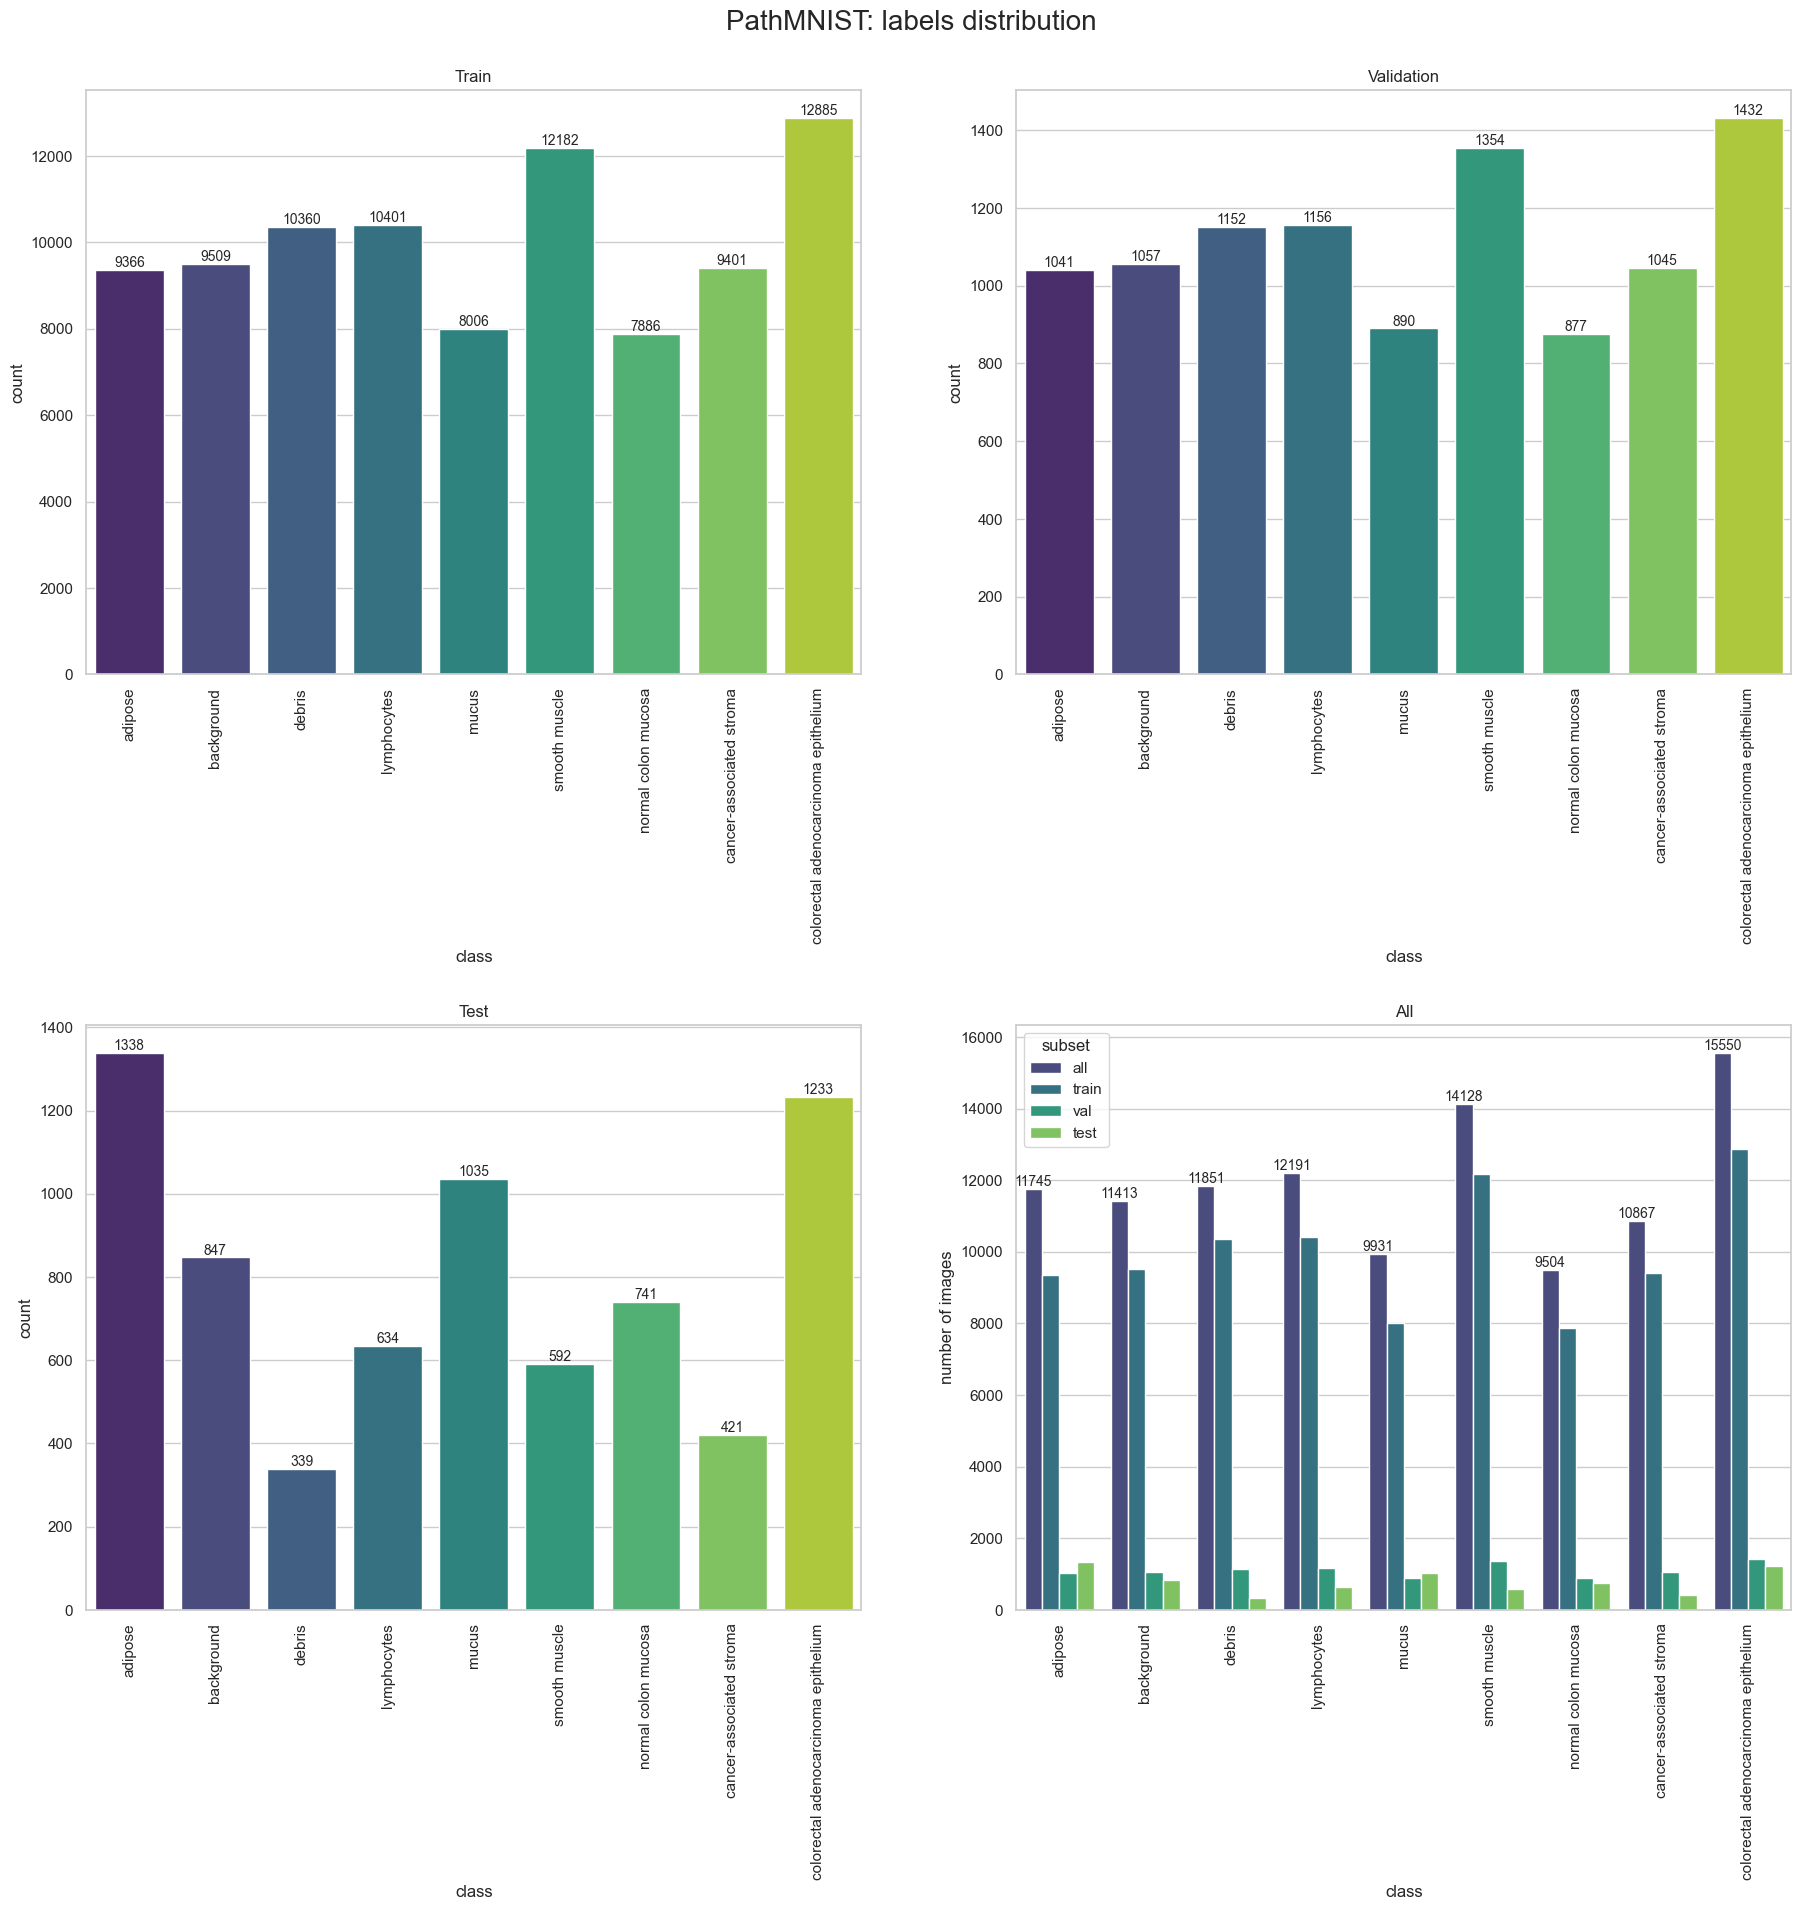

In [186]:
df_train = pd.DataFrame({"class": class_names, "count": train_counts})
df_val = pd.DataFrame({"class": class_names, "count": val_counts})
df_test = pd.DataFrame({"class": class_names, "count": test_counts})
df_all = pd.DataFrame({
    
    "class": class_names * 4,
    "count": list(all_counts) + list(train_counts) + list(val_counts) + list(test_counts),
    "subset": (
        ["all"] * n_classes +
        ["train"] * n_classes +
        ["val"]   * n_classes +
        ["test"]  * n_classes
    )
})

fig, axes = plt.subplots(2, 2, figsize=(22, 40))
ax = sns.barplot(data=df_train, x="class", y="count", palette="viridis", ax=axes[0, 0])
axes[0, 0].set_title("Train")
axes[0, 0].tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fontsize=10);

ax = sns.barplot(data=df_val, x="class", y="count", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("Validation")
axes[0, 1].tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fontsize=10);

ax = sns.barplot(data=df_test, x="class", y="count", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("Test")
axes[1, 0].tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fontsize=10);

ax = sns.barplot(data=df_all, x="class", y="count", hue="subset", palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title("All")
axes[1, 1].tick_params(axis="x", rotation=90)
ax.bar_label(ax.containers[0], fontsize=10);

fig.suptitle("PathMNIST: labels distribution", fontsize=20, y=0.9)
# plt.xlabel("tissue class", fontsize = 12)
plt.ylabel("number of images", fontsize = 12)
plt.subplots_adjust(hspace=0.6, bottom=0.5)

plt.show()

**Context**:
If bars are similar, then dataset is balanced. Otherwise (if some bars are much bigger) imbalance exists.

**Observation**:
There appears to be slight imbalance (especially between `mucus` and `colorectal adenocarcinoma epithelium` in train subset), which may bias models towards bigger classes and to ignore rarer ones.

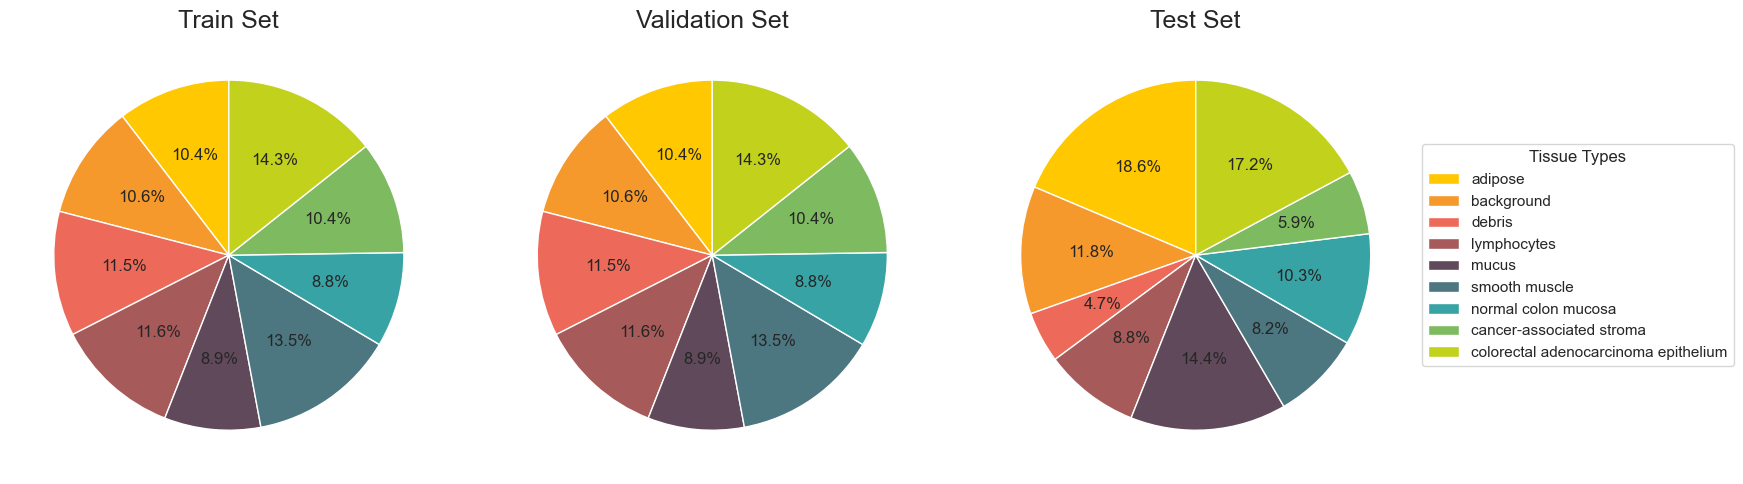

In [187]:
colors = ['#ffc800', '#f6992d', '#ed6a5a', '#a75a5a', '#60495a', '#4c7680', '#38a3a5', '#7dba60', '#c2d11b']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].pie(train_counts, autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title("Train Set", fontsize=18)

axes[1].pie(val_counts, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title("Validation Set", fontsize=18)

axes[2].pie(test_counts, autopct='%1.1f%%', startangle=90, colors=colors)
axes[2].set_title("Test Set", fontsize=18)

plt.legend(class_names, title="Tissue Types", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Random Sample Grid

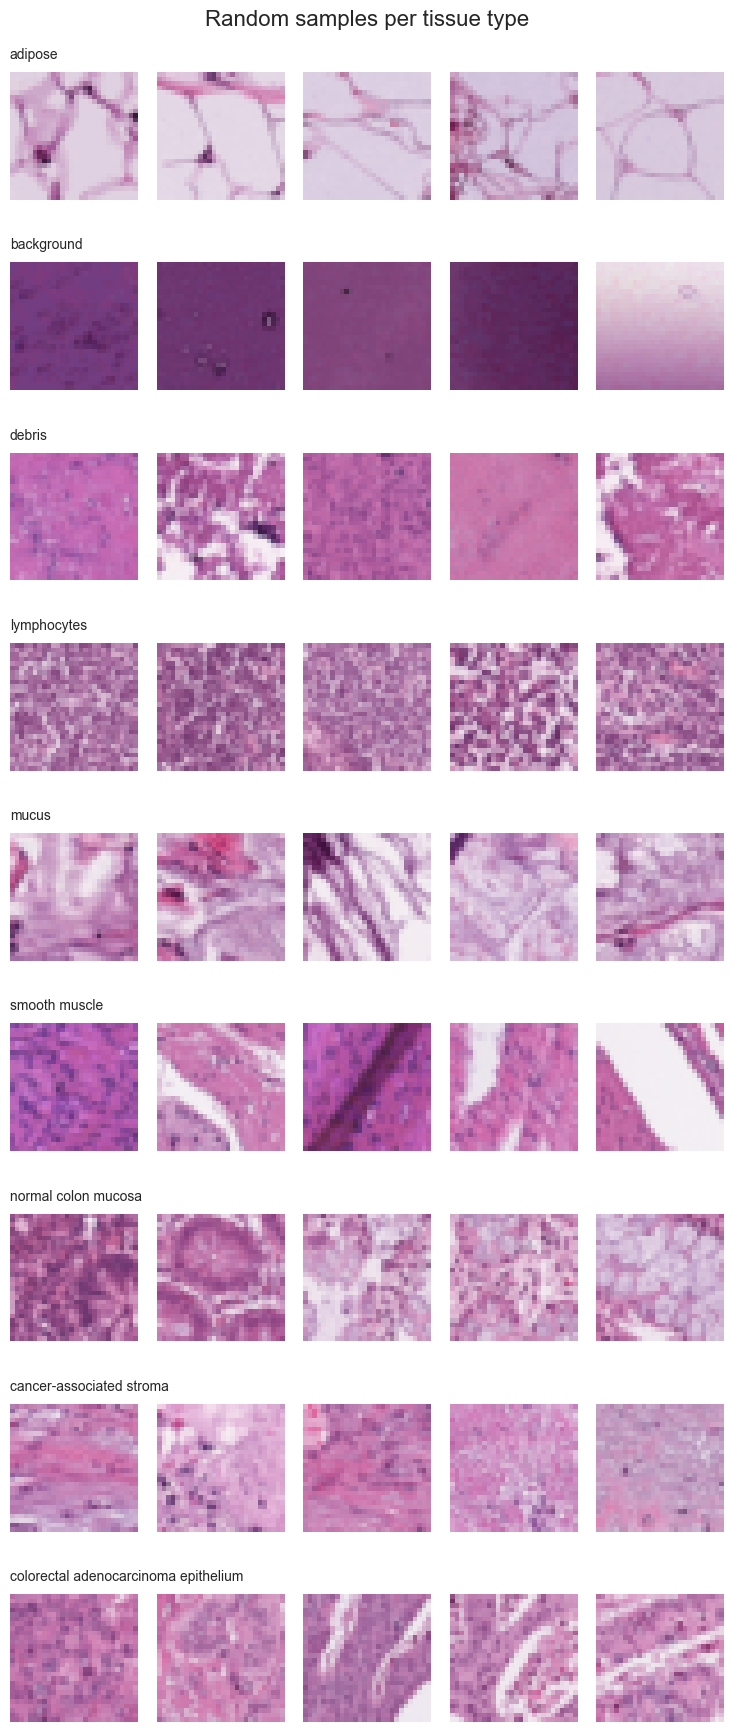

In [188]:
samples_per_class = 5

fig, axes = plt.subplots(n_classes, samples_per_class, figsize = (samples_per_class * 1.5, n_classes * 2))

for class_idx in range(n_classes):
    class_indices = np.where(train_labels == class_idx)[0]
    selected_indices = np.random.choice(class_indices, samples_per_class, replace=False)
    
    for i, idx in enumerate(selected_indices):
        ax = axes[class_idx, i]
        ax.imshow(train_images[idx])
        ax.axis('off')
        if i == 0:
            ax.set_title(class_names[class_idx], fontsize = 10, loc = 'left', pad = 10)
            
plt.suptitle("Random samples per tissue type", fontsize = 16)
plt.tight_layout(h_pad = 0.1, w_pad = 0.1)
plt.show()

**Context:**
Shows differences within the same class and how different classes look similar.

**Observation:**
We are shown real microscopic histology images. We can notice that images are very small (i.e. low resolution) and quite noisy/grainy (texture like?). These texture differences rather than shapes is what classification relies on.
Because of visual overlap between some classes and sometimes significant variety in tissue appearance, we can see how difficult and challenging classification may be.

## Pixel Intensity Distribution

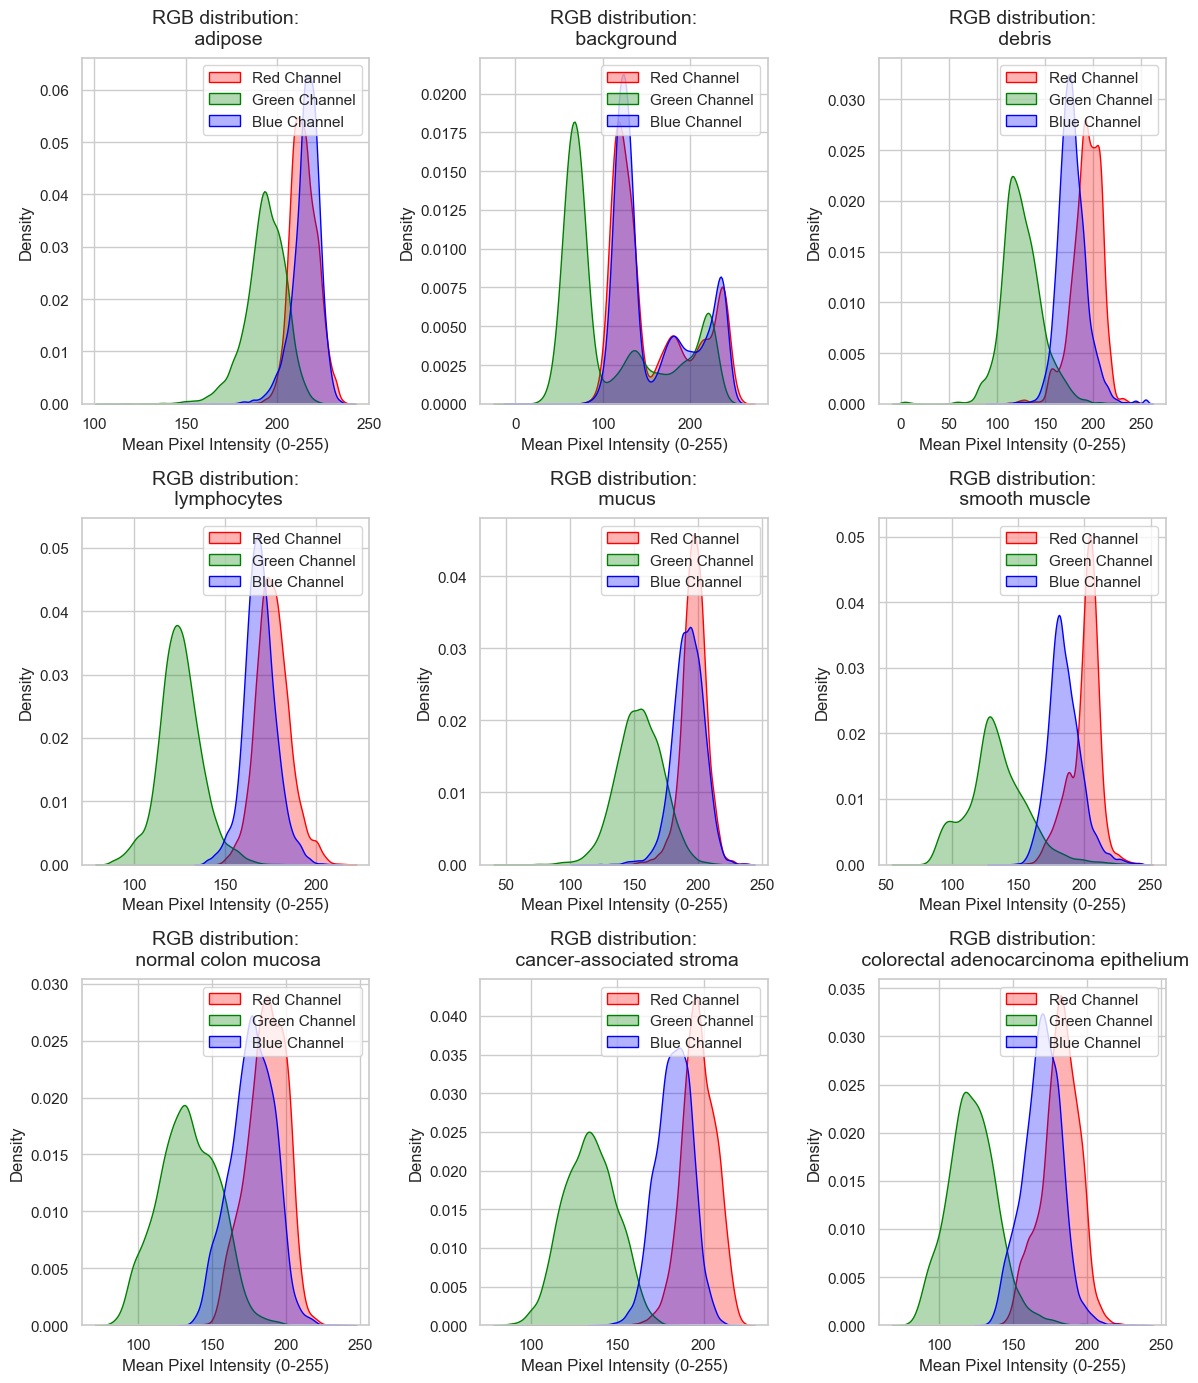

In [189]:
mean_r = np.mean(train_images[:, :, :, 0], axis = (1, 2))
mean_g = np.mean(train_images[:, :, :, 1], axis = (1, 2))
mean_b = np.mean(train_images[:, :, :, 2], axis = (1, 2))

# choosing the most distinct classes: adipose, background, debris and colorectal adenocarcinoma epithelium
target_classes = np.array(range(10))
fig, axes = plt.subplots(3, 3, figsize=(12, 14))

for i in range(1, 4):
    for j in range(1, 4):
        c = (i - 1) * 3 + (j - 1)
        class_mask = (train_labels == c)
        
        ax = axes[i-1, j-1]
        
        sns.kdeplot(mean_r[class_mask], ax = ax, color = 'red', label = 'Red Channel', fill = True, alpha = 0.3)
        sns.kdeplot(mean_g[class_mask], ax = ax, color = 'green', label = 'Green Channel', fill = True, alpha = 0.3)
        sns.kdeplot(mean_b[class_mask], ax = ax, color = 'blue', label = 'Blue Channel', fill = True, alpha = 0.3)
        
        ax.set_title(f"RGB distribution:\n {class_names[c]}", fontsize = 14, pad = 10)
        ax.set_xlabel("Mean Pixel Intensity (0-255)")
        ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

**Context:**
Overlaping curves representing red, greed and blue channel, show how bright or dark images are.

**Observation:**
Pixel intensity distribution show strong staining patterns (pink/purple coloring) and how unevenly colored images are, which is normal for histopathology images. Because of that preprocessing like normalization (rescaling features to a standardized range for stable, faster training) and augmentation (expanding dataset by creating modified copies of existing data to prevent overfitting) may be necessary.

**Note:** I don't think normalization is really necessary here (numbers are already on the same scale, range 0-255).

### Different version of plot above

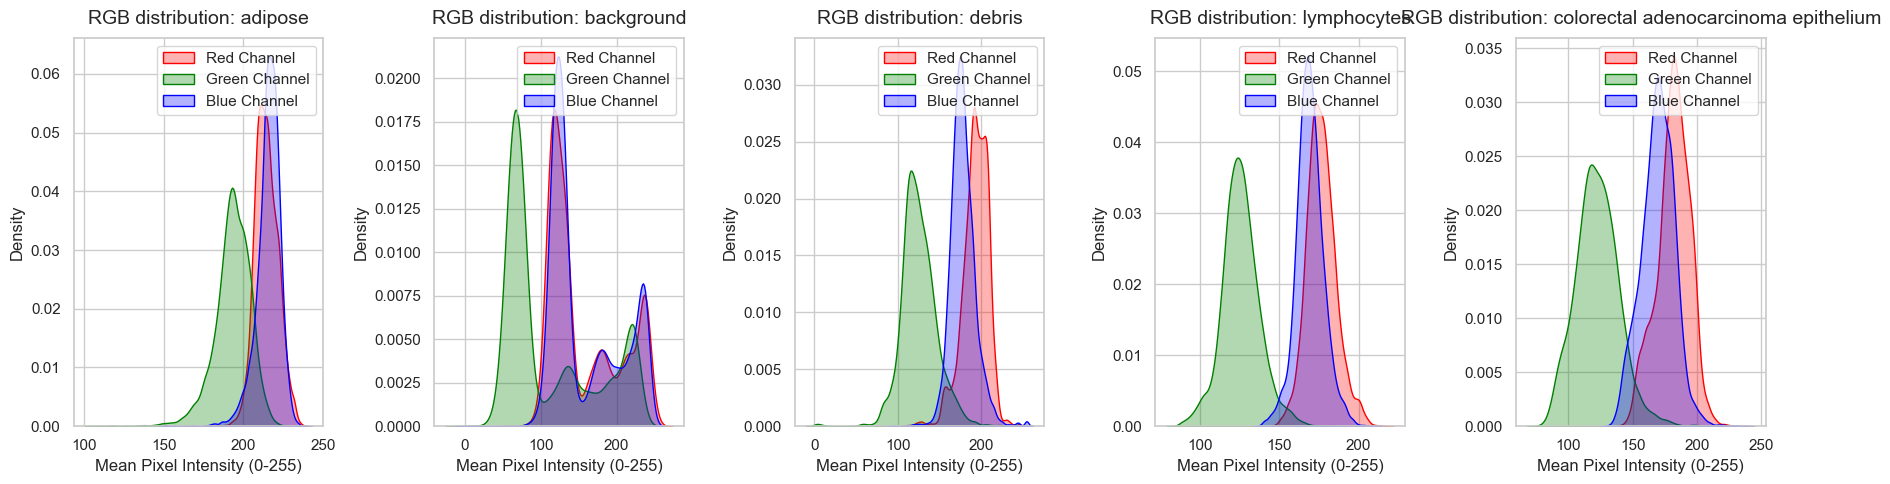

In [190]:
mean_r = np.mean(train_images[:, :, :, 0], axis = (1, 2))
mean_g = np.mean(train_images[:, :, :, 1], axis = (1, 2))
mean_b = np.mean(train_images[:, :, :, 2], axis = (1, 2))

# choosing the most distinct classes: adipose, background, debris and colorectal adenocarcinoma epithelium
target_classes = [0, 1, 2, 3, 8] 
fig, axes = plt.subplots(1, len(target_classes), figsize=(18, 5))

for idx, c in enumerate(target_classes):
    class_mask = (train_labels == c)
    
    sns.kdeplot(mean_r[class_mask], ax = axes[idx], color = 'red', label = 'Red Channel', fill = True, alpha = 0.3)
    sns.kdeplot(mean_g[class_mask], ax = axes[idx], color = 'green', label = 'Green Channel', fill = True, alpha = 0.3)
    sns.kdeplot(mean_b[class_mask], ax = axes[idx], color = 'blue', label = 'Blue Channel', fill = True, alpha = 0.3)
    
    axes[idx].set_title(f"RGB distribution: {class_names[c]}", fontsize = 14, pad = 10)
    axes[idx].set_xlabel("Mean Pixel Intensity (0-255)")
    axes[idx].set_ylabel("Density")
    axes[idx].legend()
    
plt.tight_layout()
plt.show()

### The darkest and brightest images

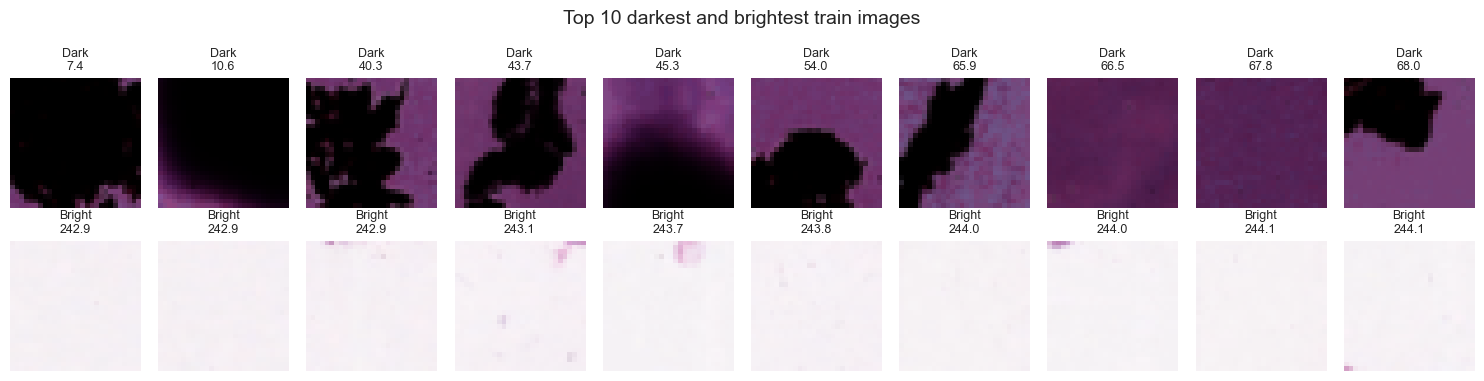

In [191]:
imgs_per_extremum = 10
mean_intensities = np.mean(train_images, axis = (1, 2, 3))
sorted_indices = np.argsort(mean_intensities)
darkest_indices = sorted_indices[:imgs_per_extremum]
brightest_indices = sorted_indices[-imgs_per_extremum:]

fig, axes = plt.subplots(2, imgs_per_extremum, figsize=(15, 4))

for i, idx in enumerate(darkest_indices):
    axes[0, i].imshow(train_images[idx])
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Dark\n{mean_intensities[idx]:.1f}", fontsize = 9)
    
for i, idx in enumerate(brightest_indices):
    axes[1, i].imshow(train_images[idx])
    axes[1, i].axis('off')
    axes[1, i].set_title(f"Bright\n{mean_intensities[idx]:.1f}", fontsize = 9)
    
plt.suptitle(f"Top {imgs_per_extremum} darkest and brightest train images", fontsize = 14)
plt.tight_layout()
plt.show()

**Observation:** 
TODO

## t-SNE Visualization

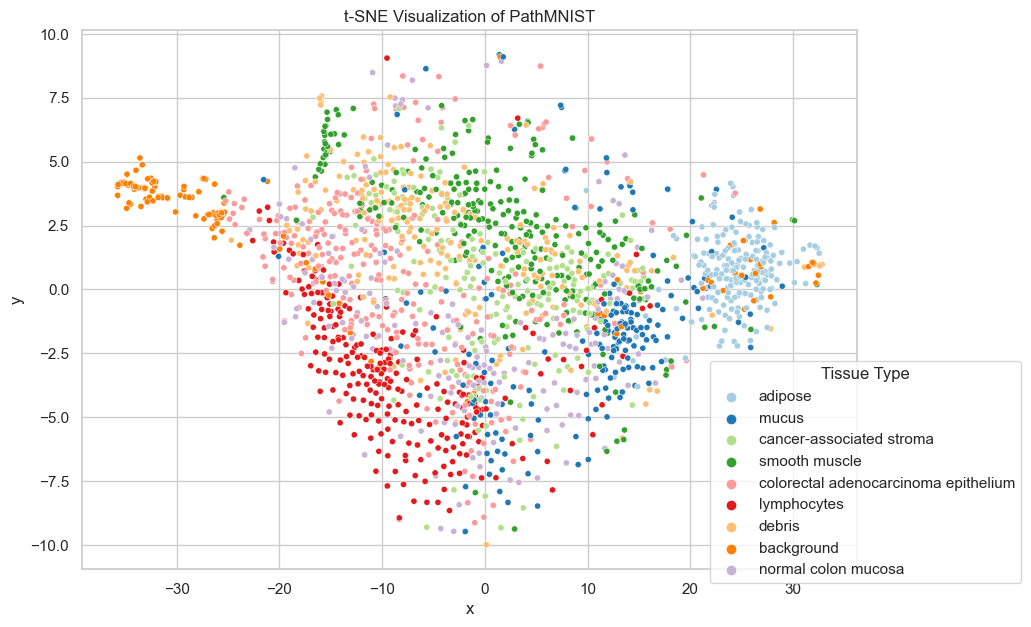

In [192]:
# Flatten images
img_flatten = train_dataset.imgs.reshape(len(x), -1)
labels_flatten = train_dataset.labels.flatten()

# Take subset (important for speed)
subset = 2000
X_subset = img_flatten[:subset]
y_subset = labels_flatten[:subset]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_subset)

df = pd.DataFrame({
    "x": X_embedded[:, 0],
    "y": X_embedded[:, 1],
    "class": [class_names[i] for i in y_subset]
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="x", y="y", hue="class", s=20, palette="Paired")

plt.legend(title="Tissue Type", bbox_to_anchor=(0.8, 0.4))
plt.title("t-SNE Visualization of PathMNIST")
plt.show()


**Context:**
Each dot is one image, each color is one class. By using t-SNE plot we may observe 3 possible patterns:
- clusters are separated
- clusters overlap (classes are mixed)
- there is no clear seperation.;

**Observation:**
Visualization shows overlapping classes, because of that dataset is not linearly separable and classification may not be straightforward.

**Note:**
CNN may be required and accuracy will not be high.
